In [ ]:
#@title Σύνδεση με Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#@title Συμπληρώστε **ακριβώς** τα στοιχεία για το project σας. Συμπληρώστε στο base_path (με copy path) το διαμοιρασμένο folder του ομαδικού project
seed = "828397636" # @param {type:"string"}

assigned_dataset = "KMNIST_RGB" # @param {type:"string"}

base_path = "/content/drive/MyDrive/CV-final-project_828397636" # @param {type:"string"}

In [ ]:
#@title δημιουργία/update values στο config.yaml
import yaml
import os

# Construct the new configuration dictionary with current values
new_config_data = {
    "project": {
        "assigned_dataset": assigned_dataset
    },
    "seed": seed,
    "paths": {
        "base_path": base_path,
        "runs_dir": os.path.join(base_path, "runs"),
        "data_dir": os.path.join(base_path, "data")
    }
}

config_path = os.path.join(base_path, "config.yaml")

# Check if config.yaml already exists
if os.path.exists(config_path):
    with open(config_path, "r") as f:
        existing_config = yaml.safe_load(f)

    # Update specific values in the existing config
    if existing_config is None: # Handle empty YAML file case
        existing_config = {}

    # Ensure 'project' key exists
    if 'project' not in existing_config:
        existing_config['project'] = {}
    existing_config['project']['assigned_dataset'] = new_config_data['project']['assigned_dataset']

    existing_config['seed'] = new_config_data['seed']

    # Ensure 'paths' key exists
    if 'paths' not in existing_config:
        existing_config['paths'] = {}
    existing_config['paths']['base_path'] = new_config_data['paths']['base_path']
    existing_config['paths']['runs_dir'] = new_config_data['paths']['runs_dir']
    existing_config['paths']['data_dir'] = new_config_data['paths']['data_dir']

    config_to_dump = existing_config
else:
    config_to_dump = new_config_data

# Write the (potentially updated) config to the file
with open(config_path, "w") as f:
    yaml.dump(config_to_dump, f, sort_keys=False)

print("Configuration created/updated successfully!\n")
print(f"Base path        : {base_path}")
print(f"Seed             : {seed}")
print(f"Assigned dataset : {assigned_dataset}")
print(f"Config file      : {config_path}")

Configuration created/updated successfully!

Base path        : /content/drive/MyDrive/CV-final-project_828397636
Seed             : 828397636
Assigned dataset : KMNIST_RGB
Config file      : /content/drive/MyDrive/CV-final-project_828397636/config.yaml


In [ ]:
#@title Εισαγωγή Βιβλιοθηκών & Προετοιμασία
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import sampler

import torchvision.datasets as dset
import torchvision.transforms as T
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt

# Ρύθμιση για εκτέλεση σε GPU (αν είναι διαθέσιμη), αλλιώς CPU
USE_GPU = True
dtype = torch.float32

if USE_GPU and torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

# Για αναπαραγωγιμότητα αποτελεσμάτων (καλή πρακτική)
# Ορίζουμε το seed για το CPU (ΠΑΝΤΑ)
torch.manual_seed(seed)

# Αν χρησιμοποιούμε GPU, ορίζουμε ΚΑΙ το seed της GPU
if device.type == 'cuda':
    torch.cuda.manual_seed_all(seed) # Για όλες τις GPUs

# Κάθε πότε θα εκτυπώνουμε το training loss
print_every = 100
print('using device:', device)

using device: cpu


In [ ]:
#@title Mean & Std
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

def calculate_stats():
    print("\n⏳ [Data Engineer]: Υπολογισμός στατιστικών KMNIST RGB...")


    datasets.KMNIST.mirrors = ['http://codh.rois.ac.jp/kmnist/dataset/kmnist/']

    transform_calc = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor()
    ])


    temp_dataset = datasets.KMNIST(root='./datasets', train=True, download=True, transform=transform_calc)


    loader = DataLoader(temp_dataset, batch_size=64, shuffle=False, num_workers=2)

    mean = 0.
    std = 0.
    total_images = 0

    for images, _ in loader:
        batch_samples = images.size(0)
        images = images.view(batch_samples, images.size(1), -1)
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
        total_images += batch_samples

    mean /= total_images
    std /= total_images

    print(f"Mean: {mean.tolist()}")
    print(f"Std:  {std.tolist()}")

if __name__ == '__main__':
    calculate_stats()


⏳ [Data Engineer]: Υπολογισμός στατιστικών KMNIST RGB...


100%|██████████| 18.2M/18.2M [00:21<00:00, 840kB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 187kB/s]
100%|██████████| 3.04M/3.04M [00:03<00:00, 869kB/s]
100%|██████████| 5.12k/5.12k [00:00<00:00, 9.03MB/s]


Mean: [0.1916271597146988, 0.1916271597146988, 0.1916271597146988]
Std:  [0.3149530589580536, 0.3149530589580536, 0.3149530589580536]


# **Data**: φόρτωμα των δεδομένων (Dataset) και την υλοποίηση των Data Augmentation

In [ ]:

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

def get_dataloaders(dataset_name, root='./datasets', batch_size=64, augment=False, input_size=32):
    stats = {
        'KMNIST_RGB': {
            'mean': [0.1916271597146988, 0.1916271597146988, 0.1916271597146988],
            'std': [0.3149530589580536, 0.3149530589580536, 0.3149530589580536]
        }
    }

    if dataset_name not in stats:
        current_mean = [0.5, 0.5, 0.5]
        current_std = [0.5, 0.5, 0.5]
    else:
        current_mean = stats[dataset_name]['mean']
        current_std = stats[dataset_name]['std']

    base_transforms = [
        transforms.Resize((input_size, input_size)),
        transforms.Grayscale(num_output_channels=3)
    ]

    train_transforms_list = base_transforms.copy()

    if augment:
        train_transforms_list.append(
            transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1))
        )

    train_transforms_list.extend([
        transforms.ToTensor(),
        transforms.Normalize(current_mean, current_std)
    ])

    val_transforms_list = base_transforms.copy() + [
        transforms.ToTensor(),
        transforms.Normalize(current_mean, current_std)
    ]

    train_transform = transforms.Compose(train_transforms_list)
    val_transform = transforms.Compose(val_transforms_list)

    # Datasets
    full_dataset = datasets.KMNIST(root=root, train=True, download=True, transform=train_transform)
    test_dataset = datasets.KMNIST(root=root, train=False, download=True, transform=val_transform)

    train_size = int(0.9 * len(full_dataset))
    val_size = len(full_dataset) - train_size

    train_dataset, _ = torch.utils.data.random_split(full_dataset, [train_size, val_size])


    val_full_dataset = datasets.KMNIST(root=root, train=True, download=True, transform=val_transform)
    _, val_dataset = torch.utils.data.random_split(val_full_dataset, [train_size, val_size])


    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    # Επιστρέφουμε 3 στοιχεία και όχι Dictionary, για να δουλέψει το επόμενο κελί
    return train_loader, val_loader, test_loader


--> Φόρτωση δεδομένων KMNIST για οπτικοποίηση...

--> Εικόνες KMNIST (Batch shape: torch.Size([64, 3, 32, 32]))


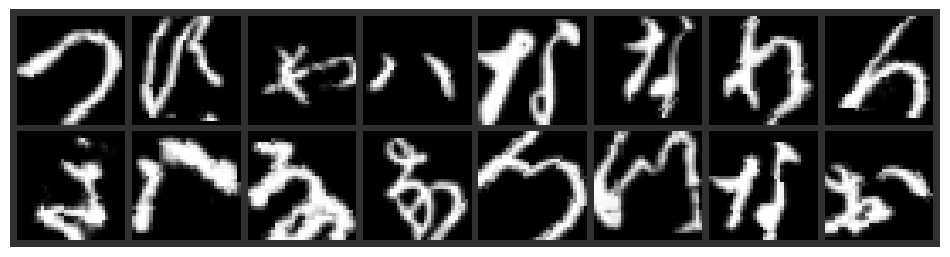


=== DATASET SPECS (Δώσε αυτά στον Architect) ===
• Image Size (Input): 32x32 pixels
• Channels:           3 (RGB)
• Number of Classes:  10 (KMNIST)
• Training Set:       54000 εικόνες
• Validation Set:     6000 εικόνες
• Test Set:           10000 εικόνες


In [ ]:

import matplotlib.pyplot as plt
import torchvision
import numpy as np

print("--> Φόρτωση δεδομένων KMNIST για οπτικοποίηση...")

train_loader, val_loader, test_loader = get_dataloaders(
    dataset_name='KMNIST_RGB',
    batch_size=64,
    augment=True
)

# 2. Παίρνουμε ένα δείγμα εικόνων
dataiter = iter(train_loader)
images, labels = next(dataiter)

# 3. Τις εμφανίζουμε σωστά (με τα πραγματικά Mean/Std)
def imshow(img):
    # Mean & Std του KMNIST_RGB
    mean = np.array([0.1916271597146988, 0.1916271597146988, 0.1916271597146988])
    std = np.array([0.3149530589580536, 0.3149530589580536, 0.3149530589580536])

    npimg = img.numpy()
    # Μετατροπή από (Channel, Height, Width) σε (Height, Width, Channel)
    npimg = np.transpose(npimg, (1, 2, 0))

    # Ξε-κανονικοποίηση (Denormalize): img * std + mean
    npimg = std * npimg + mean

    # Clip για να είμαστε σίγουροι ότι οι τιμές είναι μεταξύ 0 και 1
    npimg = np.clip(npimg, 0, 1)

    plt.imshow(npimg)
    plt.axis('off')

print(f"\n--> Εικόνες KMNIST (Batch shape: {images.shape})")

plt.figure(figsize=(12, 4))
imshow(torchvision.utils.make_grid(images[:16], nrow=8))
plt.show()



print(f"• Image Size (Input): {images.shape[2]}x{images.shape[3]} pixels")
print(f"• Channels:           {images.shape[1]} (RGB)")
print(f"• Number of Classes:  10 (KMNIST)")
print(f"• Training Set:       {len(train_loader.sampler)} εικόνες")
print(f"• Validation Set:     {len(val_loader.sampler)} εικόνες")
print(f"• Test Set:           {len(test_loader.dataset)} εικόνες")


# **Model**: Αρχιτεκτονική μοντέλου CNN

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CustomCNN(nn.Module):
    def __init__(self, input_channels=3, num_classes=10, use_bn=True, dropout_rate=0.5):
        """
        Αρχιτεκτονική 4 Blocks για KMNIST (RGB 32x32).
        Διαστάσεις: 32 -> 16 -> 8 -> 4 -> 2x2
        ΠΕΡΙΟΡΙΣΜΟΣ CPU: Max Channels = 128.
        """
        super(CustomCNN, self).__init__()

        # --- ΟΡΙΣΜΟΣ LAYERS (__init__) ---

        # Block 1: 32x32 -> 16x16
        self.conv1 = nn.Conv2d(input_channels, 32, kernel_size=5, padding=2)
        if use_bn: self.bn1 = nn.BatchNorm2d(32)

        # Block 2: 16x16 -> 8x8
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        if use_bn: self.bn2 = nn.BatchNorm2d(64)

        # Block 3: 8x8 -> 4x4
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        if use_bn: self.bn3 = nn.BatchNorm2d(128)

        # Block 4: 4x4 -> 2x2 (Deep features)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        if use_bn: self.bn4 = nn.BatchNorm2d(128)

        # Classifier Head
        # Flatten: 128 channels * 2 * 2 pixels = 512
        self.flatten_dim = 128 * 2 * 2

        # Dropout
        self.dropout = nn.Dropout(p=dropout_rate) if dropout_rate > 0 else nn.Identity()

        # Fully Connected
        self.fc = nn.Linear(self.flatten_dim, num_classes)

    def forward(self, x):
        # --- ΡΟΗ ΔΕΔΟΜΕΝΩΝ (forward) ---

        # Block 1
        x = self.conv1(x)
        if hasattr(self, 'bn1'): x = self.bn1(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)

        # Block 2
        x = self.conv2(x)
        if hasattr(self, 'bn2'): x = self.bn2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)

        # Block 3
        x = self.conv3(x)
        if hasattr(self, 'bn3'): x = self.bn3(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)

        # Block 4
        x = self.conv4(x)
        if hasattr(self, 'bn4'): x = self.bn4(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)

        # Classifier Head
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)

        return x



In [ ]:
def get_simple_cnn(input_channels=3, num_classes=10):
    return CustomCNN(input_channels, num_classes)



# **Train**: συνάρτηση εκπαίδευσης του μοντέλου

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import os
import copy
import time


# Helper Class: Early Stopping

class EarlyStopping:
    def __init__(self, patience=5, delta=0):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0


def train_engine(model, loaders, epochs, learning_rate, experiment_name,
                 base_dir='runs', checkpoint_save=5, resume=False, checkpoint_path=None,
                 patience=10):

    # Έλεγχος συσκευής
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # Ενώνουμε το base_path (Drive) + runs + όνομα πειράματος
    try:
        exp_dir = os.path.join(base_path, base_dir, experiment_name)
    except NameError:
        print("--> [Warning]: Το base_path δεν βρέθηκε. Αποθήκευση τοπικά.")
        exp_dir = os.path.join(base_dir, experiment_name)

    os.makedirs(exp_dir, exist_ok=True)

    # Logs
    log_dir = os.path.join(exp_dir, 'logs')
    os.makedirs(log_dir, exist_ok=True)
    log_file_path = os.path.join(log_dir, 'train_log.txt')

    print(f"--> [System]: Αποθήκευση στο: {exp_dir}")

    # Μεταφορά μοντέλου
    model = model.to(device)


    optimizer = optim.Adam(model.parameters(), lr=learning_rate)


    start_epoch = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'times': []}
    best_val_acc = 0.0


    early_stopping = EarlyStopping(patience=patience, delta=0.001)


    if resume:
        load_path = checkpoint_path if checkpoint_path else os.path.join(exp_dir, 'last_checkpoint.pth')
        if os.path.isfile(load_path):
            print(f"--> [System]: Φόρτωση checkpoint από {load_path}")
            checkpoint = torch.load(load_path, map_location=device)
            model.load_state_dict(checkpoint['model_state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            start_epoch = checkpoint['epoch'] + 1
            history = checkpoint['history']
            best_val_acc = checkpoint.get('best_val_acc', 0.0)

            if 'times' not in history: history['times'] = []
        else:
            print(f"--> [Warning]: Δεν βρέθηκε checkpoint. Έναρξη από την αρχή.")

    print(f"--> [Exp]: {experiment_name} | Device: {device} | Patience: {patience}")

    # --- TRAINING LOOP ---
    total_start_time = time.time()

    for e in range(start_epoch, epochs):
        epoch_start_time = time.time()


        model.train()
        train_loss_cum = 0.0
        train_correct = 0
        train_total = 0

        for x, y in loaders['train']:
            x = x.to(device)
            y = y.to(device, dtype=torch.long)

            optimizer.zero_grad()
            scores = model(x)
            loss = F.cross_entropy(scores, y)
            loss.backward()
            optimizer.step()

            train_loss_cum += loss.item() * x.size(0)
            _, preds = scores.max(1)
            train_correct += (preds == y).sum().item()
            train_total += x.size(0)

        avg_train_loss = train_loss_cum / train_total
        avg_train_acc = 100 * train_correct / train_total

        # 2. Validation Phase
        model.eval()
        val_loss_cum = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for x, y in loaders['val']:
                x = x.to(device)
                y = y.to(device, dtype=torch.long)

                scores = model(x)
                loss = F.cross_entropy(scores, y)

                val_loss_cum += loss.item() * x.size(0)
                _, preds = scores.max(1)
                val_correct += (preds == y).sum().item()
                val_total += x.size(0)

        avg_val_loss = val_loss_cum / val_total
        avg_val_acc = 100 * val_correct / val_total

        # 3. Time Measurement & Logging
        epoch_end_time = time.time()
        epoch_duration = epoch_end_time - epoch_start_time

        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(avg_train_acc)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(avg_val_acc)
        history['times'].append(epoch_duration)

        log_msg = (f"Epoch {e+1:03d}/{epochs} | Time: {epoch_duration:.1f}s | "
                   f"Tr Loss: {avg_train_loss:.4f} Acc: {avg_train_acc:.2f}% | "
                   f"Val Loss: {avg_val_loss:.4f} Acc: {avg_val_acc:.2f}%")

        print(log_msg)
        with open(log_file_path, 'a') as f:
            f.write(log_msg + '\n')

        # 4. Checkpointing
        current_epoch_checkpoint = {
            'epoch': e,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'history': history,
            'best_val_acc': best_val_acc
        }

        if checkpoint_save > 0:
            if ((e + 1) % checkpoint_save == 0) or (e + 1 == epochs):
                torch.save(current_epoch_checkpoint, os.path.join(exp_dir, 'last_checkpoint.pth'))

        if avg_val_acc > best_val_acc:
            best_val_acc = avg_val_acc
            current_epoch_checkpoint['best_val_acc'] = best_val_acc
            torch.save(current_epoch_checkpoint, os.path.join(exp_dir, 'best_model.pth'))
            # print(f"    --> New Best Model! ({best_val_acc:.2f}%)")

        # 5. Early Stopping Check
        early_stopping(avg_val_loss)
        if early_stopping.early_stop:
            print(f"--> [System]: Early Stopping ενεργοποιήθηκε στην εποχή {e+1}.")
            with open(log_file_path, 'a') as f:
                f.write(f"--> [System]: Early Stopping triggered at epoch {e+1}\n")
            break

    total_time = time.time() - total_start_time
    print(f"--> [Exp]: Ολοκληρώθηκε σε {total_time:.1f}s. Best Val Acc: {best_val_acc:.2f}%")

    return history, model

# **Utils**: συναρτήσεις για στάδια workflow

In [ ]:
import matplotlib.pyplot as plt

def evaluate_on_test(model, test_loader):
    """ Τελική αξιολόγηση στο Test Set """
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device)
            scores = model(x)
            _, preds = scores.max(1)
            correct += (preds == y).sum().item()
            total += x.size(0)

    acc = 100 * correct / total
    print(f"\n--> [Test Set Evaluation]: Accuracy = {acc:.2f}%")
    return acc

def plot_history(history, title="Training History"):
    """
    οπτικοποίηση καμπυλών μάθησης.
    """
    plt.style.use('seaborn-v0_8-darkgrid') # Πιο καθαρό στυλ
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(title, fontsize=16)

    # Loss
    ax1.plot(history['train_loss'], label='Train Loss', linewidth=2, color='tab:blue')
    ax1.plot(history['val_loss'], label='Val Loss', linewidth=2, color='tab:orange', linestyle='--')
    ax1.set_title('Loss Evolution')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Cross Entropy Loss')
    ax1.legend()
    ax1.grid(True)

    # Accuracy
    ax2.plot(history['train_acc'], label='Train Acc', linewidth=2, color='tab:green')
    ax2.plot(history['val_acc'], label='Val Acc', linewidth=2, color='tab:red', linestyle='--')
    ax2.set_title('Accuracy Evolution')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)

    plt.show()

# **FULL CV PIPELINE**

In [ ]:
#@title 1. Prepare data & model
t_loader, v_loader, test_loader = get_dataloaders(
    dataset_name=assigned_dataset,
    augment=False,
    batch_size=32
)

# Επαλήθευση διαστάσεων
if t_loader:
    # Λήψη ενός batch για έλεγχο
    images, labels = next(iter(t_loader))
    print(f"\nΈλεγχος Batch για {assigned_dataset}:")
    print(f"Διαστάσεις Εικόνων: {images.shape}") # Πρέπει να είναι [32, 3, 32, 32]
    print(f"Τύπος Δεδομένων: {images.dtype}")
    print(f"Εύρος Τιμών (περίπου): {images.min():.2f} έως {images.max():.2f}")

model = get_simple_cnn(input_channels=3, num_classes=10)
dummy_input = torch.randn(1, 3, 32, 32)

try:
    output = model(dummy_input)
    print(f"--> [Success]: Output shape: {output.shape}")
except RuntimeError as e:
    print(f"--> [Error]: {e}")
    print("Συμβουλή: Αν προσθέσατε Block, ξεχάσατε να διαιρέσετε το current_size δια 2;")


Έλεγχος Batch για KMNIST_RGB:
Διαστάσεις Εικόνων: torch.Size([32, 3, 32, 32])
Τύπος Δεδομένων: torch.float32
Εύρος Τιμών (περίπου): -0.61 έως 2.57
--> [Success]: Output shape: torch.Size([1, 10])


In [ ]:
#@title 2. Initial Loss Check
import torch
import math

x, y = next(iter(t_loader))
out = model(x)
loss = torch.nn.functional.cross_entropy(out, y)
init_loss = loss.item()
num_classes = 10 # Define num_classes
expected_loss = math.log(num_classes)

print(f"Initial loss: {init_loss:.4f}, Expected ln(num_classes): {expected_loss:.4f}")

Initial loss: 2.6091, Expected ln(num_classes): 2.3026


In [ ]:
# -------------------------------
#@title 3. Sanity Check (Overfit tiny batch)
# -------------------------------
import torch
from torch.utils.data import TensorDataset, DataLoader
import copy # Εισαγωγή της βιβλιοθήκης copy για τη δημιουργία αντιγράφων

# Δημιουργία ενός προσωρινού αντιγράφου του μοντέλου για το sanity check
# Αυτό διασφαλίζει ότι οι αρχικοί βάροι του μοντέλου δεν επηρεάζονται.
temp_model = copy.deepcopy(model)

# Λήψη ενός batch από τον αρχικό εκπαιδευτικό loader
x_batch, y_batch = next(iter(t_loader))

# Επιλογή ενός πολύ μικρού υποσυνόλου (π.χ. τα πρώτα 10 δείγματα)
tiny_x = x_batch[:10]
tiny_y = y_batch[:10]

# Δημιουργία ενός TensorDataset από αυτό το μικρό υποσύνολο
tiny_dataset = TensorDataset(tiny_x, tiny_y)

# Δημιουργία ενός DataLoader για αυτό το μικρό dataset
# Το shuffle ορίζεται σε False για συνέπεια κατά το sanity check
tiny_loader = DataLoader(tiny_dataset, batch_size=10, shuffle=False)

# Προετοιμασία λεξικού loaders για τη συνάρτηση train_engine
# Για το sanity check, μπορούμε να χρησιμοποιήσουμε τον ίδιο tiny_loader για εκπαίδευση και επικύρωση
sanity_check_loaders = {'train': tiny_loader, 'val': tiny_loader, 'test': None}


train_engine(temp_model, sanity_check_loaders,
             experiment_name="sanity_check_overfit_tiny_batch",
             learning_rate=0.001,
             epochs=50,
             checkpoint_save=5)


--> [System]: Αποθήκευση στο: /content/drive/MyDrive/CV-final-project_828397636/runs/sanity_check_overfit_tiny_batch
--> [Exp]: sanity_check_overfit_tiny_batch | Device: cpu | Patience: 10
Epoch 001/50 | Time: 0.1s | Tr Loss: 2.9655 Acc: 0.00% | Val Loss: 2.1559 Acc: 60.00%
Epoch 002/50 | Time: 0.1s | Tr Loss: 0.8238 Acc: 70.00% | Val Loss: 1.9846 Acc: 70.00%
Epoch 003/50 | Time: 0.1s | Tr Loss: 0.3787 Acc: 100.00% | Val Loss: 1.8070 Acc: 100.00%
Epoch 004/50 | Time: 0.1s | Tr Loss: 0.2766 Acc: 90.00% | Val Loss: 1.6095 Acc: 100.00%
Epoch 005/50 | Time: 0.1s | Tr Loss: 0.1276 Acc: 100.00% | Val Loss: 1.4085 Acc: 100.00%
Epoch 006/50 | Time: 0.1s | Tr Loss: 0.0690 Acc: 100.00% | Val Loss: 1.2078 Acc: 100.00%
Epoch 007/50 | Time: 0.1s | Tr Loss: 0.0771 Acc: 100.00% | Val Loss: 1.0163 Acc: 100.00%
Epoch 008/50 | Time: 0.1s | Tr Loss: 0.0692 Acc: 100.00% | Val Loss: 0.8346 Acc: 100.00%
Epoch 009/50 | Time: 0.1s | Tr Loss: 0.0546 Acc: 100.00% | Val Loss: 0.6674 Acc: 100.00%
Epoch 010/50 | T

({'train_loss': [2.9654505252838135,
   0.823807418346405,
   0.3786913752555847,
   0.2765952944755554,
   0.12764719128608704,
   0.06896953284740448,
   0.07706885039806366,
   0.06920894235372543,
   0.05462285876274109,
   0.04362546280026436,
   0.04016400873661041,
   0.02800782397389412,
   0.016553707420825958,
   0.020088383927941322,
   0.03230585902929306,
   0.02076452597975731,
   0.008566760458052158,
   0.011833617463707924,
   0.027998197823762894,
   0.0054551842622458935,
   0.003745100926607847,
   0.0040734149515628815,
   0.005704569164663553,
   0.007008074317127466,
   0.0032060290686786175,
   0.0022843151818960905,
   0.002486384706571698,
   0.0014588148333132267,
   0.005404268391430378,
   0.0039759790524840355,
   0.003029306186363101,
   0.0030769151635468006,
   0.0036590234376490116,
   0.0021482512820512056,
   0.00667083403095603,
   0.0016314319800585508,
   0.0027581267058849335,
   0.0009320940007455647,
   0.0038449664134532213,
   0.0011056760558

In [ ]:

# @title 2 & 3. Architect Report
# Τα απο πάνω check χρησιμοποίθηκαν μόνο για αναφορά,και τα 2 χρησιμοποιούνται τώρα για τα καθήκοντα του architect.
import torch
import math
import copy
import os
from torch.utils.data import TensorDataset, DataLoader


main_runs_dir = "/content/drive/MyDrive/CV-final-project_828397636/runs"
architect_save_dir = os.path.join(main_runs_dir, "architect_checks")


if not os.path.exists(architect_save_dir):
    os.makedirs(architect_save_dir)
    print(f"--> [System]: Created directory {architect_save_dir}")

report_file_path = os.path.join(architect_save_dir, "architect_report.txt")

# Λίστα με τα 3 σενάρια
scenarios = [
    ("Baseline (No BN, No Drop)", False, 0.0),
    ("With Batch Norm Only",      True,  0.0),
    ("Final (BN + Dropout 0.5)",  True,  0.5)
]

results = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Λήψη σταθερού batch
fixed_x, fixed_y = next(iter(t_loader))
fixed_x, fixed_y = fixed_x.to(device), fixed_y.to(device)




with open(report_file_path, "w") as f:
    f.write("=== ARCHITECTURAL DESIGN VALIDATION REPORT ===\n\n")

    for name, use_bn, dropout_rate in scenarios:
        print(f"\n>> Testing Model: {name}")
        f.write(f"Experiment: {name}\n")
        f.write(f"Settings: BN={use_bn}, Drop={dropout_rate}\n")


        model = CustomCNN(input_channels=3, num_classes=10,
                          use_bn=use_bn, dropout_rate=dropout_rate).to(device)

        # ----------------------------------------------------------------
        # STEP 2: INITIAL LOSS CHECK
        # ----------------------------------------------------------------
        model.eval()
        with torch.no_grad():
            out = model(fixed_x)
            loss = torch.nn.functional.cross_entropy(out, fixed_y)
            init_loss = loss.item()

        expected_loss = math.log(10)
        log_init = f"  Initial loss: {init_loss:.4f} (Expected: {expected_loss:.4f})"
        print(log_init)
        f.write(log_init + "\n")

        # ----------------------------------------------------------------
        # STEP 3: SANITY CHECK - OVERFIT TINY BATCH
        # ----------------------------------------------------------------
        temp_model = copy.deepcopy(model)

        tiny_x = fixed_x[:10]
        tiny_y = fixed_y[:10]
        tiny_dataset = TensorDataset(tiny_x, tiny_y)
        tiny_loader = DataLoader(tiny_dataset, batch_size=10, shuffle=False)
        sanity_check_loaders = {'train': tiny_loader, 'val': tiny_loader, 'test': None}

        print(f"   Running Overfit Check (40 epochs)...")

        exp_name = f"sanity_{name.replace(' ', '_').replace('(', '').replace(')', '')}"

        history, _ = train_engine(temp_model, sanity_check_loaders,
                                  experiment_name=exp_name,
                                  learning_rate=0.001,
                                  epochs=40,
                                  checkpoint_save=0,
                                  base_dir=architect_save_dir)

        final_loss = history['train_loss'][-1]
        log_overfit = f"    Final Tiny Batch Loss: {final_loss:.5f}"
        print(log_overfit)
        f.write(log_overfit + "\n")

        status = "SUCCESS" if final_loss < 0.1 else "FAIL"
        results.append((name, init_loss, final_loss, status))
        f.write(f"   Status: {status}\n")
        f.write("-" * 40 + "\n")


    header = f"\n{'Experiment':<30} | {'Init Loss':<10} | {'Tiny Loss':<10} | {'Status'}"
    divider = "-" * 70

    print("                       ARCHITECT'S FINAL REPORT")

    print(header)
    print(divider)

    f.write("\n\n=== FINAL SUMMARY TABLE ===\n")
    f.write(header + "\n")
    f.write(divider + "\n")

    for res in results:
        line = f"{res[0]:<30} | {res[1]:<10.4f} | {res[2]:<10.5f} | {res[3]}"
        print(line)
        f.write(line + "\n")

    print("-" * 70)
    print(f"--> [System]: Report saved to {report_file_path}")


model = CustomCNN(input_channels=3, num_classes=10, use_bn=True, dropout_rate=0.5).to(device)



>> Testing Model: Baseline (No BN, No Drop)
  Initial loss: 2.3036 (Expected: 2.3026)
   Running Overfit Check (40 epochs)...
--> [System]: Αποθήκευση στο: /content/drive/MyDrive/CV-final-project_828397636/runs/architect_checks/sanity_Baseline_No_BN,_No_Drop
--> [Exp]: sanity_Baseline_No_BN,_No_Drop | Device: cpu | Patience: 10
Epoch 001/40 | Time: 0.1s | Tr Loss: 2.3033 Acc: 10.00% | Val Loss: 2.1519 Acc: 40.00%
Epoch 002/40 | Time: 0.0s | Tr Loss: 2.1519 Acc: 40.00% | Val Loss: 1.9580 Acc: 30.00%
Epoch 003/40 | Time: 0.1s | Tr Loss: 1.9580 Acc: 30.00% | Val Loss: 1.7406 Acc: 30.00%
Epoch 004/40 | Time: 0.0s | Tr Loss: 1.7406 Acc: 30.00% | Val Loss: 1.6686 Acc: 30.00%
Epoch 005/40 | Time: 0.1s | Tr Loss: 1.6686 Acc: 30.00% | Val Loss: 1.5089 Acc: 60.00%
Epoch 006/40 | Time: 0.0s | Tr Loss: 1.5089 Acc: 60.00% | Val Loss: 1.3397 Acc: 70.00%
Epoch 007/40 | Time: 0.0s | Tr Loss: 1.3397 Acc: 70.00% | Val Loss: 1.1727 Acc: 100.00%
Epoch 008/40 | Time: 0.0s | Tr Loss: 1.1727 Acc: 100.00% | 


--> [LR Finder]: Δοκιμάζω LR: 1e-05
--> [System]: Αποθήκευση στο: /content/drive/MyDrive/CV-final-project_828397636/runs/lrfinder/lr_1e-05
--> [Exp]: lr_1e-05 | Device: cpu | Patience: 10
Epoch 001/1 | Time: 209.2s | Tr Loss: 1.8993 Acc: 35.21% | Val Loss: 1.1327 Acc: 74.30%
--> [Exp]: Ολοκληρώθηκε σε 209.2s. Best Val Acc: 74.30%
    Result for LR 1e-05: Val Acc = 74.30%

--> [LR Finder]: Δοκιμάζω LR: 0.0001
--> [System]: Αποθήκευση στο: /content/drive/MyDrive/CV-final-project_828397636/runs/lrfinder/lr_0_0001
--> [Exp]: lr_0_0001 | Device: cpu | Patience: 10
Epoch 001/1 | Time: 201.7s | Tr Loss: 0.9399 Acc: 70.91% | Val Loss: 0.2848 Acc: 93.12%
--> [Exp]: Ολοκληρώθηκε σε 201.7s. Best Val Acc: 93.12%
    Result for LR 0.0001: Val Acc = 93.12%

--> [LR Finder]: Δοκιμάζω LR: 0.001
--> [System]: Αποθήκευση στο: /content/drive/MyDrive/CV-final-project_828397636/runs/lrfinder/lr_0_001
--> [Exp]: lr_0_001 | Device: cpu | Patience: 10
Epoch 001/1 | Time: 206.4s | Tr Loss: 0.4218 Acc: 86.72% 

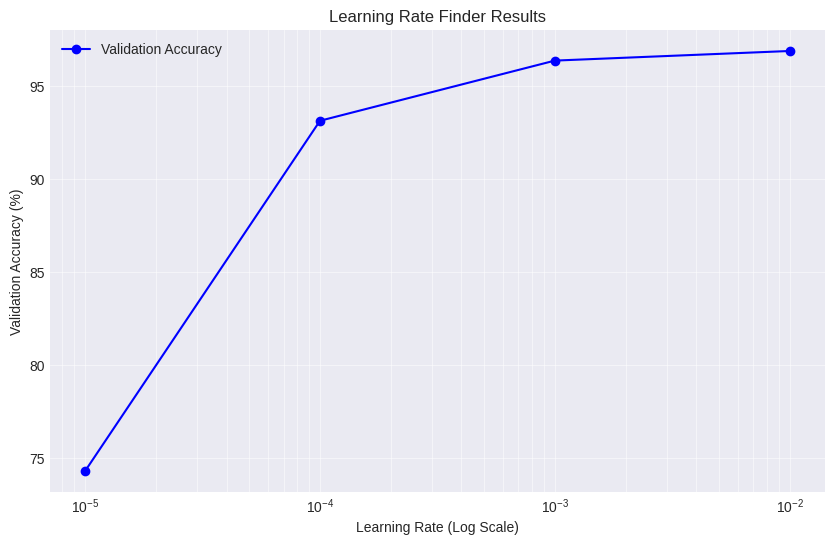


--> [LR Finder]: Το γράφημα εμφανίστηκε.
    Καλύτερη Ακρίβεια: 96.87% με LR: 0.01
--> Ορίστηκε αυτόματα: best_lr = 0.01


In [ ]:

#@title 4. Learning Rate Finder (Με Γράφημα & Αυτόματη Επιλογή)

import copy
import os
import matplotlib.pyplot as plt

# Ορισμός της λίστας των Learning Rates προς δοκιμή
lrs = [1e-5, 1e-4, 1e-3, 1e-2]


val_accuracies = []

# Δημιουργία του λεξικού loaders (train & val μόνο χρειάζονται εδώ)
loaders = {'train': t_loader, 'val': v_loader, 'test': None}



main_runs_dir = "/content/drive/MyDrive/CV-final-project_828397636/runs"

lr_save_dir = os.path.join(main_runs_dir, "lrfinder")



for lr_val in lrs:
    print(f"\n--> [LR Finder]: Δοκιμάζω LR: {lr_val}")

    # 1. Δημιουργία προσωρινού αντιγράφου του μοντέλου
    temp_model = copy.deepcopy(model)

    # 2. Όνομα πειράματος (π.χ. lr_0_001)
    experiment_name = f"lr_{str(lr_val).replace('.', '_')}"

    # 3. Εκπαίδευση για 1 εποχή

    history, _ = train_engine(
        temp_model,
        loaders,
        epochs=1,
        learning_rate=lr_val,
        experiment_name=experiment_name,
        base_dir=lr_save_dir,
        checkpoint_save=0
    )

    # 4. Αποθήκευση της τελικής ακρίβειας (Validation Accuracy)
    final_acc = history['val_acc'][-1]
    val_accuracies.append(final_acc)
    print(f"    Result for LR {lr_val}: Val Acc = {final_acc:.2f}%")


print("\n--> [LR Finder]: Δημιουργία Γραφήματος...")

plt.figure(figsize=(10, 6))
plt.plot(lrs, val_accuracies, marker='o', linestyle='-', color='b', label='Validation Accuracy')
plt.xscale('log') #
plt.title('Learning Rate Finder Results')
plt.xlabel('Learning Rate (Log Scale)')
plt.ylabel('Validation Accuracy (%)')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()


# Επιλογή Best LR


best_acc_index = val_accuracies.index(max(val_accuracies))
suggested_lr = lrs[best_acc_index]

print(f"\n--> [LR Finder]: Το γράφημα εμφανίστηκε.")
print(f"    Καλύτερη Ακρίβεια: {max(val_accuracies):.2f}% με LR: {suggested_lr}")

best_lr = suggested_lr
print(f"--> Ορίστηκε αυτόματα: best_lr = {best_lr}")

In [ ]:

# @title Step 4: Coarse Grid Search

import time
import os
import torch
import copy


DATASET_NAME = 'KMNIST_RGB'
ROOT_PATH = './datasets'


main_runs_dir = "/content/drive/MyDrive/CV-final-project_828397636/runs"

# PART 1: BATCH SIZE EXPERIMENT

batch_sizes = [32, 64, 128]
fixed_lr_for_bs = 0.001 # Σταθερό LR για τη σύγκριση των Batch Sizes
bs_save_dir = os.path.join(main_runs_dir, "batch_exp")


print(f"--> Batch Size Experiment ")


print(f"{'Batch':<10} | {'Time/Epoch (s)':<15} | {'Val Acc (%)':<15}")


results_bs = []

for bs in batch_sizes:
    try:
        # 1. Δημιουργία Loaders
        t_load, v_load, _ = get_dataloaders(
            dataset_name=DATASET_NAME,
            root=ROOT_PATH,
            batch_size=bs,
            augment=False,
            input_size=32
        )
        loaders_b = {'train': t_load, 'val': v_load, 'test': None}

        # 2. Φρέσκο Μοντέλο
        temp_model = CustomCNN(input_channels=3, num_classes=10).to(device)

        # 3. Εκπαίδευση (3 Εποχές για ταχύτητα)
        history, _ = train_engine(
            temp_model,
            loaders_b,
            epochs=3,
            learning_rate=fixed_lr_for_bs,
            experiment_name=f"batch_size_{bs}",
            base_dir=bs_save_dir,
            checkpoint_save=0,
            patience=5
        )

        # 4. Υπολογισμός Μέσου Χρόνου (αγνοούμε την 1η εποχή συνήθως λόγω initialization overhead)
        if history['times'] and len(history['times']) > 1:
            avg_time = sum(history['times'][1:]) / (len(history['times']) - 1)
        elif history['times']:
            avg_time = history['times'][0]
        else:
            avg_time = 0

        final_acc = history['val_acc'][-1] if history['val_acc'] else 0.0

        print(f"{bs:<10} | {avg_time:<15.2f} | {final_acc:<15.2f}")
        results_bs.append((bs, avg_time, final_acc))

    except Exception as e:
        print(f"{bs:<10} | FAIL ({str(e)})")

# Επιλογή Νικητή Batch Size (Βάσει Χρόνου - Μικρότερο καλύτερο)
if results_bs:
    results_bs.sort(key=lambda x: x[1]) # Sort by Time (Ascending)
    best_bs = results_bs[0][0]
    print("-" * 45)
    print(f"--> Το Batch Size {best_bs} επιλέχθηκε ως το γρηγορότερο.")
else:
    best_bs = 64 # Fallback
    print("--> [ERROR]: Κάτι πήγε στραβά, fallback σε BS=64")




print("\n--> Επαναφόρτωση DataLoaders με το Best Batch Size...")
t_loader, v_loader, test_loader = get_dataloaders(
    dataset_name=DATASET_NAME,
    root=ROOT_PATH,
    batch_size=best_bs,
    augment=False,
    input_size=32
)

loaders = {'train': t_loader, 'val': v_loader, 'test': test_loader}



# PART 2: LR COARSE GRID (Using Best Batch Size)

lr_list = [0.005, 0.01, 0.02]
coarse_save_dir = os.path.join(main_runs_dir, "coarse_grid")


print(f"--> Coarse LR Search (Target: Accuracy)")
print(f"--> Using Batch Size: {best_bs}")



results_lr = []

for lr_val in lr_list:
    print(f"--> Testing LR: {lr_val}")


    temp_model = CustomCNN(input_channels=3, num_classes=10).to(device)

    # 2. Εκπαίδευση (2 Εποχές)
    history, _ = train_engine(
        temp_model,
        loaders, # Αυτοί είναι οι loaders με το best_bs
        epochs=2,
        learning_rate=lr_val,
        experiment_name=f"coarse_lr_{str(lr_val).replace('.', '_')}",
        base_dir=coarse_save_dir,
        checkpoint_save=0
    )

    # 3. Καταγραφή
    if history['val_acc']:
        final_acc = history['val_acc'][-1]
        results_lr.append((lr_val, final_acc))
        print(f"    Result: LR {lr_val} -> Val Acc: {final_acc:.2f}%")
    else:
        results_lr.append((lr_val, 0.0))

# Επιλογή Νικητή LR (Βάσει Ακρίβειας - Μεγαλύτερο καλύτερο)
print("-" * 45)
if results_lr:
    results_lr.sort(key=lambda x: x[1], reverse=True) # Sort by Acc (Descending)
    best_lr = results_lr[0][0]
    best_acc = results_lr[0][1]
    print(f"--> [WINNER]: Το Learning Rate {best_lr} πέτυχε τη μέγιστη ακρίβεια ({best_acc:.2f}%)")
else:
    best_lr = 0.001
    print("--> [ERROR]: Fallback σε LR=0.001")



print("  FINAL CONFIGURATION (Ready for Step 5)")
print("#"*30)
print(f"  Best Batch Size : {best_bs}")
print(f"  Best Learn Rate : {best_lr}")

--> Batch Size Experiment 
Batch      | Time/Epoch (s)  | Val Acc (%)    
--> [System]: Αποθήκευση στο: /content/drive/MyDrive/CV-final-project_828397636/runs/batch_exp/batch_size_32
--> [Exp]: batch_size_32 | Device: cpu | Patience: 5
Epoch 001/3 | Time: 234.2s | Tr Loss: 0.2281 Acc: 93.01% | Val Loss: 0.0630 Acc: 98.25%
Epoch 002/3 | Time: 208.5s | Tr Loss: 0.0865 Acc: 97.35% | Val Loss: 0.0381 Acc: 98.78%
Epoch 003/3 | Time: 208.8s | Tr Loss: 0.0644 Acc: 98.06% | Val Loss: 0.0278 Acc: 99.17%
--> [Exp]: Ολοκληρώθηκε σε 651.7s. Best Val Acc: 99.17%
32         | 208.69          | 99.17          
--> [System]: Αποθήκευση στο: /content/drive/MyDrive/CV-final-project_828397636/runs/batch_exp/batch_size_64
--> [Exp]: batch_size_64 | Device: cpu | Patience: 5
Epoch 001/3 | Time: 199.9s | Tr Loss: 0.2409 Acc: 92.75% | Val Loss: 0.0847 Acc: 97.40%
Epoch 002/3 | Time: 201.3s | Tr Loss: 0.0869 Acc: 97.37% | Val Loss: 0.0474 Acc: 98.62%
Epoch 003/3 | Time: 203.5s | Tr Loss: 0.0616 Acc: 98.09% | 

In [ ]:

# @title Step 6: Refined Grid Search

import copy
import os
import torch

main_runs_dir = "/content/drive/MyDrive/CV-final-project_828397636/runs"
refined_save_dir = os.path.join(main_runs_dir, "refined_grid")



aug_train_loader, aug_val_loader, aug_test_loader = get_dataloaders(
    dataset_name='KMNIST_RGB',
    root='./datasets',
    batch_size=best_bs,
    augment=True,
    input_size=32
)

# Ενημέρωση του λεξικού loaders
loaders = {'train': aug_train_loader, 'val': aug_val_loader, 'test': aug_test_loader}


refined_lrs = [best_lr]

# Αυξάνουμε τις εποχές (20-30) όπως ζητάει η εκφώνηση
epochs_refined = 20

results_refined = []

print("="*60)
print(f"--> [Refined Grid Search]: Έναρξη για {epochs_refined} εποχές.")
print(f"--> Log Directory: {refined_save_dir}")
print("="*60)

for lr_val in refined_lrs:
    print(f"\n--> [Refined Grid Search]: Δοκιμάζω LR: {lr_val}")


    try:
        # Αντικατέστησε το CustomCNN αν η κλάση σου λέγεται αλλιώς
        temp_model = CustomCNN(input_channels=3, num_classes=10).to(device)
    except NameError:
        print("--> [ERROR]: Δεν βρέθηκε η κλάση CustomCNN. Ελέγξτε το όνομα.")
        break

    # Β. Όνομα πειράματος
    experiment_name = f"refined_aug_lr_{str(lr_val).replace('.', '_')}"

    # Γ. Εκπαίδευση
    # Αυξάνουμε το patience γιατί το loss θα χοροπηδάει λόγω augmentation
    history, _ = train_engine(
        temp_model,
        loaders,
        epochs=epochs_refined,
        learning_rate=lr_val,
        experiment_name=experiment_name,
        base_dir=refined_save_dir,
        checkpoint_save=5,         # Αποθήκευση μοντέλου κάθε 5 εποχές
        patience=10                # Μεγαλύτερη υπομονή
    )

    # Δ. Συλλογή αποτελεσμάτων
    if history['val_acc']:
        final_acc = history['val_acc'][-1]
        results_refined.append((lr_val, final_acc))
        print(f"--> [Refined Result]: LR {lr_val} - Final Val Acc: {final_acc:.2f}%")
    else:
        results_refined.append((lr_val, 0.0))


print("  REFINED GRID RESULTS (With Augmentation)")

for lr, acc in results_refined:
    print(f"  LR: {lr:<10} | Final Val Acc: {acc:.2f}%")


final_best_lr = results_refined[0][0]


--> [Refined Grid Search]: Έναρξη για 20 εποχές.
--> Log Directory: /content/drive/MyDrive/CV-final-project_828397636/runs/refined_grid

--> [Refined Grid Search]: Δοκιμάζω LR: 0.01
--> [System]: Αποθήκευση στο: /content/drive/MyDrive/CV-final-project_828397636/runs/refined_grid/refined_aug_lr_0_01
--> [Exp]: refined_aug_lr_0_01 | Device: cpu | Patience: 10
Epoch 001/20 | Time: 199.7s | Tr Loss: 0.4987 Acc: 84.12% | Val Loss: 0.0862 Acc: 97.45%
Epoch 002/20 | Time: 201.7s | Tr Loss: 0.1581 Acc: 95.01% | Val Loss: 0.0537 Acc: 98.22%
Epoch 003/20 | Time: 200.9s | Tr Loss: 0.1279 Acc: 96.03% | Val Loss: 0.0414 Acc: 98.67%
Epoch 004/20 | Time: 200.3s | Tr Loss: 0.1190 Acc: 96.29% | Val Loss: 0.0471 Acc: 98.62%
Epoch 005/20 | Time: 200.9s | Tr Loss: 0.1088 Acc: 96.74% | Val Loss: 0.0428 Acc: 98.53%
Epoch 006/20 | Time: 203.5s | Tr Loss: 0.1020 Acc: 96.97% | Val Loss: 0.0541 Acc: 98.35%
Epoch 007/20 | Time: 200.3s | Tr Loss: 0.0954 Acc: 97.13% | Val Loss: 0.0282 Acc: 99.15%
Epoch 008/20 | Ti

--> [Config]: Batch Size=64, LR=0.01, Epochs=20

--> [Full Training]: Έναρξη πλήρους εκπαίδευσης...
--> [Storage]: Τα logs αποθηκεύονται στο: /content/drive/MyDrive/CV-final-project_828397636/runs/full_training_final_best
--> [System]: Αποθήκευση στο: /content/drive/MyDrive/CV-final-project_828397636/runs/full_training_final_best
--> [Exp]: full_training_final_best | Device: cpu | Patience: 10
Epoch 001/20 | Time: 217.0s | Tr Loss: 0.4880 Acc: 84.39% | Val Loss: 0.1067 Acc: 96.98%
Epoch 002/20 | Time: 205.1s | Tr Loss: 0.1675 Acc: 94.71% | Val Loss: 0.0541 Acc: 98.22%
Epoch 003/20 | Time: 203.8s | Tr Loss: 0.1288 Acc: 95.99% | Val Loss: 0.0384 Acc: 98.80%
Epoch 004/20 | Time: 204.6s | Tr Loss: 0.1163 Acc: 96.44% | Val Loss: 0.0354 Acc: 99.07%
Epoch 005/20 | Time: 201.2s | Tr Loss: 0.1114 Acc: 96.60% | Val Loss: 0.0382 Acc: 98.97%
Epoch 006/20 | Time: 204.3s | Tr Loss: 0.1051 Acc: 96.89% | Val Loss: 0.0299 Acc: 99.18%
Epoch 007/20 | Time: 204.5s | Tr Loss: 0.0963 Acc: 97.05% | Val Loss:

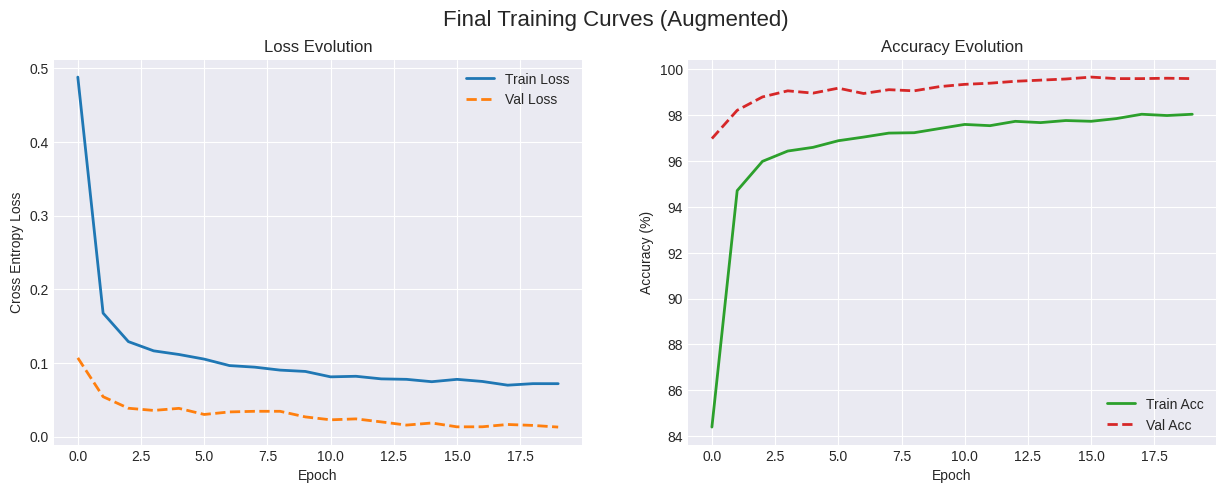

In [ ]:

# @title 7. Full Training with train/val curves (Step 5 & 6)

import os
import copy
import torch


main_runs_dir = "/content/drive/MyDrive/CV-final-project_828397636/runs"

ining = 'full_training_final_best'
lr_full_training = 0.01
epochs_full_training = 20
save_checkpoint_freq = 5


try:
    final_bs = best_bs
except NameError:
    final_bs = 64

print(f"--> [Config]: Batch Size={final_bs}, LR={lr_full_training}, Epochs={epochs_full_training}")


t_loader, v_loader, test_loader = get_dataloaders(
    dataset_name='KMNIST_RGB',
    root='./datasets',
    augment=True,
    batch_size=final_bs,
    input_size=32
)
loaders = {'train': t_loader, 'val': v_loader, 'test': test_loader}

# 3. Αρχικοποίηση 'καθαρού' μοντέλου
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
try:
    final_model = CustomCNN().to(device)
except NameError:
    print("--> [Error]: Η κλάση CustomCNN δεν βρέθηκε. Ελέγξτε τα προηγούμενα κελιά.")
    # Fallback σε deepcopy αν υπάρχει παλιό instance
    # final_model = copy.deepcopy(model)

# 4. Έναρξη Εκπαίδευσης
print(f"\n--> [Full Training]: Έναρξη πλήρους εκπαίδευσης...")
print(f"--> [Storage]: Τα logs αποθηκεύονται στο: {main_runs_dir}/{run_name_full_training}")

history, trained_model = train_engine(
    final_model,
    loaders,
    epochs=epochs_full_training,
    learning_rate=lr_full_training,
    experiment_name=run_name_full_training,
    base_dir=main_runs_dir,    # <--- Αποθήκευση στο Drive
    checkpoint_save=save_checkpoint_freq,
    resume=False,
    patience=10                # Υπομονή για το Augmentation
)

# --- ΕΜΦΑΝΙΣΗ ΚΑΜΠΥΛΩΝ (Step 6) ---

print("\n--> [Curve Analysis]: Δημιουργία διαγραμμάτων...")
try:
    plot_history(history, title="Final Training Curves (Augmented)")
except Exception as e:
    print(f"Δεν ήταν δυνατή η προβολή γραφήματος ({e}), ελέγξτε τα αρχεία στο Drive.")


# -------------------------------
# @title Κώδικας για συνέχιση εκπαίδευσης (Backup - Uncomment if needed)
# -------------------------------
# """
# # Χρησιμοποίησέ το ΜΟΝΟ αν κοπεί η σύνδεση (Disconnect)
#
# run_name_to_resume = 'full_training_final_best'
#
# # Ψάχνουμε το checkpoint στο Drive
# checkpoint_dir = os.path.join(main_runs_dir, run_name_to_resume)
# latest_checkpoint_path = os.path.join(checkpoint_dir, 'last_checkpoint.pth')
#
# print(f"\n--> [Resume Training]: Προσπάθεια συνέχισης από {latest_checkpoint_path}")
#
# # Φτιάχνουμε νέο instance μοντέλου (θα φορτωθούν τα βάρη αυτόματα από το train_engine)
# model_to_resume = CustomCNN().to(device)
#
# history, trained_model = train_engine(
#     model_to_resume,
#     loaders,
#     epochs=epochs_full_training,
#     learning_rate=lr_full_training,
#     experiment_name=run_name_to_resume,
#     base_dir=main_runs_dir, # Drive Path
#     checkpoint_save=save_checkpoint_freq,
#     resume=True,            # <--- ΕΝΕΡΓΟΠΟΙΗΣΗ RESUME
#     checkpoint_path=latest_checkpoint_path
# )
# """

--> [Test Set]: Ξεκινάει η αξιολόγηση...

--> [Test Set Evaluation]: Overall Test Accuracy = 97.70%
 ΕΠΙΤΥΧΙΑ! Ο στόχος (>93%) επιτεύχθηκε.

--> [Test Set Evaluation]: Per-Class Accuracy:
    Class 0: 97.30%
    Class 1: 98.10%
    Class 2: 96.10%
    Class 3: 98.40%
    Class 4: 96.60%
    Class 5: 97.20%
    Class 6: 97.00%
    Class 7: 98.40%
    Class 8: 99.30%
    Class 9: 98.60%


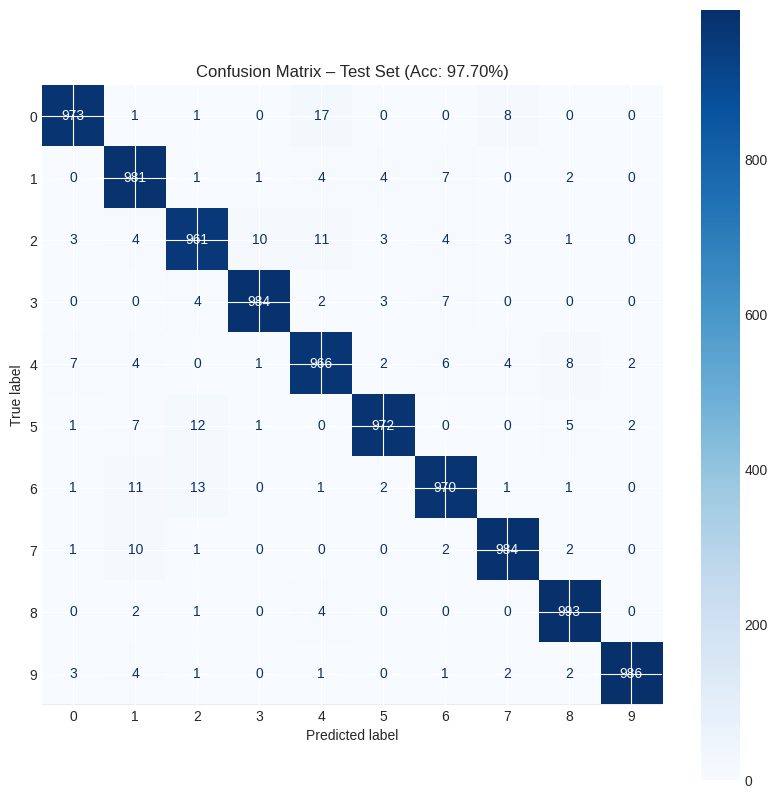


--> [Step 6]: Training & Validation Curves


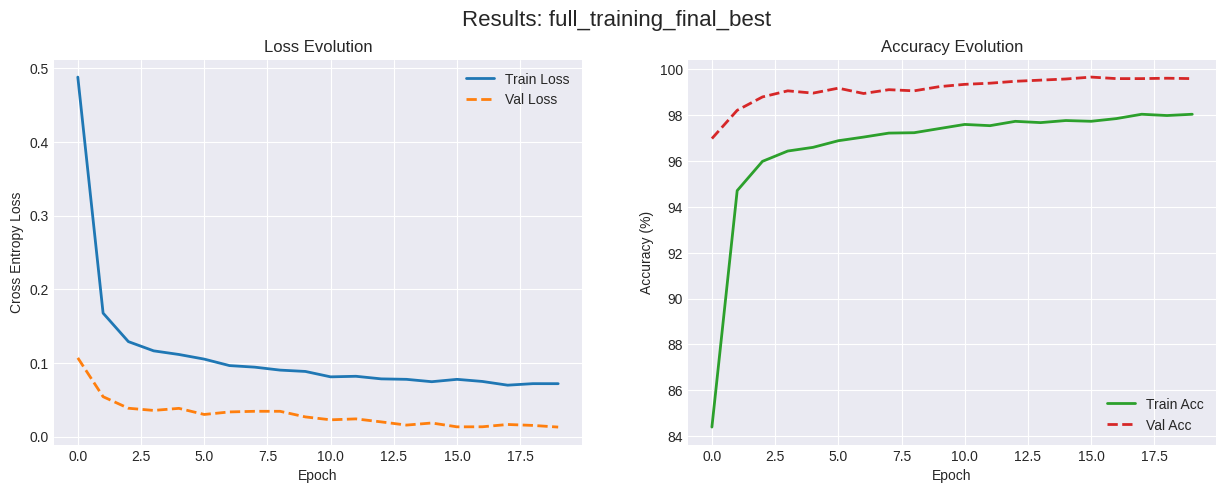

In [ ]:

# @title 8. Evaluate on Test Set & Plot Confusion Matrix

import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Ρυθμίσεις (Απαραίτητες για να μην κρασάρει ο κώδικας)
num_classes = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Προετοιμασία
# Βεβαιωθείτε ότι χρησιμοποιούμε το εκπαιδευμένο μοντέλο από το προηγούμενο βήμα
model_for_evaluation = trained_model.to(device)
model_for_evaluation.eval() # Θέτουμε το μοντέλο σε λειτουργία αξιολόγησης

all_preds = []
all_labels = []

print("--> [Test Set]: Ξεκινάει η αξιολόγηση...")

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_for_evaluation(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Test accuracy
accuracy = sum([p==l for p,l in zip(all_preds, all_labels)]) / len(all_labels)
print(f"\n--> [Test Set Evaluation]: Overall Test Accuracy = {accuracy*100:.2f}%")

# Έλεγχος Στόχου (Analyst Check)
if accuracy * 100 > 93.0:
    print(" ΕΠΙΤΥΧΙΑ! Ο στόχος (>93%) επιτεύχθηκε.")
else:
    print("ΠΡΟΣΟΧΗ! Ο στόχος δεν επιτεύχθηκε.")

# Per-class accuracy
class_correct = list(0. for i in range(num_classes))
class_total = list(0. for i in range(num_classes))
for i in range(len(all_labels)):
    label = all_labels[i]
    pred = all_preds[i]
    if label == pred:
        class_correct[label] += 1
    class_total[label] += 1

print("\n--> [Test Set Evaluation]: Per-Class Accuracy:")
for i in range(num_classes):
    if class_total[i] > 0:
        print(f"    Class {i}: {100 * class_correct[i] / class_total[i]:.2f}%")
    else:
        print(f"    Class {i}: No samples found.")

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=list(range(num_classes)))

# Χρήση fig, ax για να είμαστε σίγουροι ότι το μέγεθος θα είναι σωστό
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title(f"Confusion Matrix – Test Set (Acc: {accuracy*100:.2f}%)")
plt.show()


# @title 9. Plot Train/Validation Loss & Accuracy Curves


# Η συνάρτηση plot_history χρησιμοποιεί το 'history' που επιστρέφει η train_engine
if 'history' in locals():
    print("\n--> [Step 6]: Training & Validation Curves")
    # Χρησιμοποιούμε το όνομα run_name_full_training αν υπάρχει, αλλιώς ένα γενικό
    title_name = run_name_full_training if 'run_name_full_training' in locals() else "Final Results"
    plot_history(history, title=f"Results: {title_name}")
else:
    print("Warning: Το 'history' δεν βρέθηκε στη μνήμη.")

--> [Inference]: Αναζήτηση εικόνων για την Κλάση 8...
--> [Visualization]: Εμφάνιση 10 δειγμάτων.


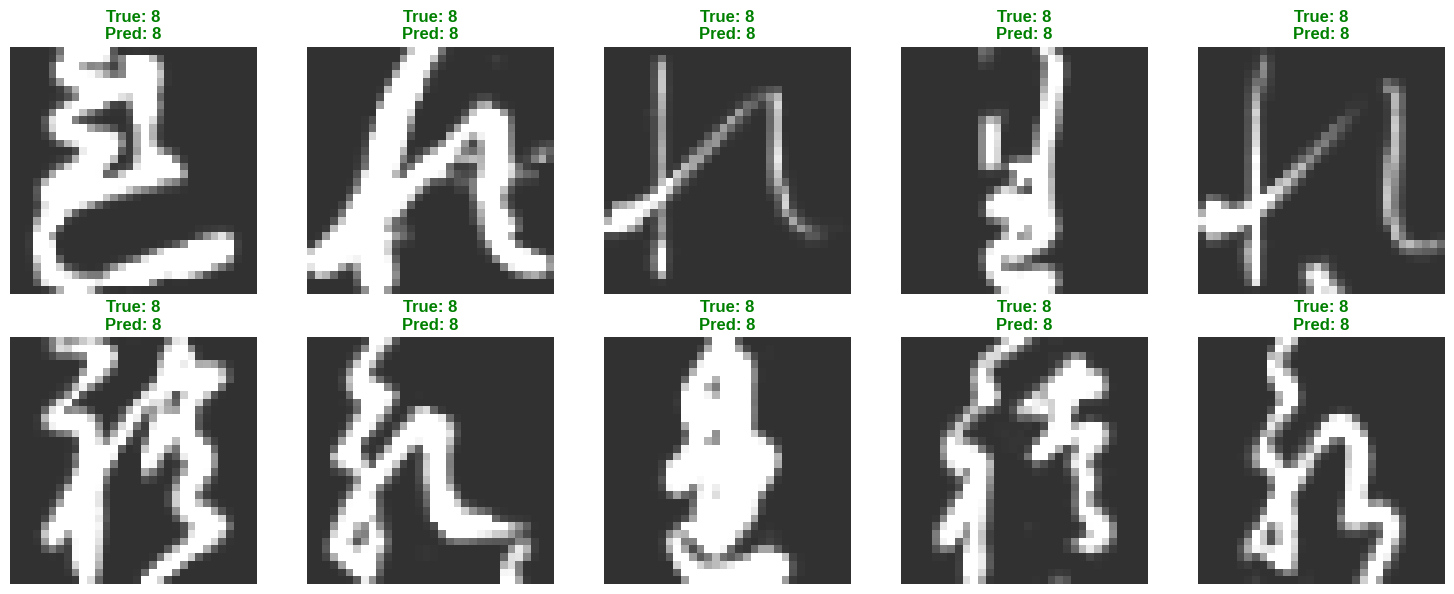

In [ ]:
# -------------------------------
# @title 10. Visualize Predictions (Inference) for Class 8
# -------------------------------
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision.transforms as T

# 1. Ρυθμίσεις
# Ορίζουμε το dataset για να ξέρει ο unnormalize ποια stats να χρησιμοποιήσει
assigned_dataset = 'KMNIST_RGB'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_of_interest = 8  # Κλάση που θέλουμε να εξετάσουμε (στο KMNIST το 8 είναι το 're')

# 2. Συνάρτηση Unnormalize (για να φαίνονται σωστά τα χρώματα)
def unnormalize(img_tensor, dataset_name):
    stats = {
        'SVHN':             {'mean': [0.4377, 0.4438, 0.4728], 'std': [0.1980, 0.2010, 0.1970]},
        'KMNIST_RGB':       {'mean': [0.5, 0.5, 0.5],          'std': [0.5, 0.5, 0.5]},
        'FashionMNIST_RGB': {'mean': [0.5, 0.5, 0.5],          'std': [0.5, 0.5, 0.5]},
    }

    # Ανάκτηση στατιστικών
    if dataset_name not in stats:
        # Fallback αν δεν βρεθεί το όνομα
        mean = [0.5, 0.5, 0.5]
        std = [0.5, 0.5, 0.5]
    else:
        mean = stats[dataset_name]['mean']
        std = stats[dataset_name]['std']

    current_mean = torch.tensor(mean).view(3, 1, 1)
    current_std = torch.tensor(std).view(3, 1, 1)

    # Αντιστροφή: img * std + mean
    unnormalized_img = img_tensor * current_std + current_mean
    return torch.clamp(unnormalized_img, 0, 1)

# 3. Συλλογή Εικόνων
class_images = []
class_labels = []
class_preds = []

# Βεβαιωθείτε ότι το 'trained_model' είναι φορτωμένο
model_viz = trained_model.to(device)
model_viz.eval()

print(f"--> [Inference]: Αναζήτηση εικόνων για την Κλάση {class_of_interest}...")

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model_viz(images)
        _, predicted = torch.max(outputs, 1)

        # Φιλτράρισμα για την συγκεκριμένη κλάση
        mask = (labels == class_of_interest)
        if mask.sum() > 0:
            class_images.extend(images[mask].cpu())
            class_labels.extend(labels[mask].cpu())
            class_preds.extend(predicted[mask].cpu())

        # Σταματάμε αν μαζέψουμε αρκετές (π.χ. 10) για να μην γεμίσουμε τη μνήμη
        if len(class_images) >= 10:
            break

# 4. Απεικόνιση
num_show = min(len(class_images), 10)
if num_show == 0:
    print(f"Δεν βρέθηκαν δείγματα για την κλάση {class_of_interest}.")
else:
    print(f"--> [Visualization]: Εμφάνιση {num_show} δειγμάτων.")
    fig = plt.figure(figsize=(15, 6))

    for i in range(num_show):
        ax = fig.add_subplot(2, 5, i + 1, xticks=[], yticks=[])

        # Unnormalize και μετατροπή για matplotlib (C,H,W -> H,W,C)
        img_display = unnormalize(class_images[i], assigned_dataset)
        np_img = img_display.permute(1, 2, 0).numpy()

        ax.imshow(np_img)

        # Τίτλος: Πράσινο αν είναι σωστό, Κόκκινο αν είναι λάθος
        is_correct = (class_preds[i] == class_labels[i])
        color = 'green' if is_correct else 'red'
        ax.set_title(f"True: {class_labels[i].item()}\nPred: {class_preds[i].item()}", color=color, fontweight='bold')

    plt.tight_layout()
    plt.show()

In [ ]:
#@title Δημιουργία zip για υποβολή
import os
import zipfile

# Define the base path (assuming it's already defined from previous cells)
# Example: base_path = "/content/drive/MyDrive/CV-final-project_1235737896"

# Define the name of the output zip file
# It will be named after the base_path directory, with '_submission.zip' appended
zip_filename = os.path.basename(base_path) + "_submission.zip"
# The zip file will be created inside the base_path for easy access
zip_path = os.path.join(base_path, zip_filename)

# Check if the base_path exists before proceeding
if not os.path.exists(base_path):
    print(f"Error: The base path '{base_path}' does not exist. Please check your 'base_path' variable.")
else:
    print(f"--> [Zip Creator]: Creating zip archive: {zip_path}")

    # Create a ZipFile object in write mode
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        # Walk through the base directory
        for root, dirs, files in os.walk(base_path):
            for file in files:
                file_path = os.path.join(root, file)

                # Define criteria for files to be excluded
                exclude_extensions = ['.pth', '.pt', '.ckpt'] # Common checkpoint extensions
                # Specific checkpoint names (though usually covered by extensions)
                exclude_names = ['last_checkpoint.pth', 'best_model.pth']

                should_exclude = False

                # Exclude based on extension
                for ext in exclude_extensions:
                    if file_path.lower().endswith(ext):
                        should_exclude = True
                        break

                # If not excluded by extension, check specific names
                if not should_exclude:
                    for name in exclude_names:
                        if file.lower() == name.lower():
                            should_exclude = True
                            break

                # Exclude the zip file itself if it's inside the base_path
                if file_path == zip_path:
                    should_exclude = True

                if should_exclude:
                    print(f"    --> [Zip Creator]: Skipping excluded file: {file_path}")
                    continue

                # Create a relative path for the file inside the zip archive.
                # This ensures the zip's internal structure starts from the base_path's contents.
                arcname = os.path.relpath(file_path, base_path)

                # Add the file to the zip archive
                if os.path.isfile(file_path): # Double-check it's a file, though os.walk 'files' list should ensure this
                    print(f"    --> [Zip Creator]: Adding {file_path} as {arcname}")
                    zipf.write(file_path, arcname)

    print(f"--> [Zip Creator]: Successfully created zip archive: {zip_path}")
    print("You can find your submission zip file in your Google Drive at the base_path location.")


--> [Zip Creator]: Creating zip archive: /content/drive/MyDrive/CV-final-project_828397636/CV-final-project_828397636_submission.zip
    --> [Zip Creator]: Adding /content/drive/MyDrive/CV-final-project_828397636/config.yaml as config.yaml
    --> [Zip Creator]: Skipping excluded file: /content/drive/MyDrive/CV-final-project_828397636/CV-final-project_828397636_submission.zip
    --> [Zip Creator]: Skipping excluded file: /content/drive/MyDrive/CV-final-project_828397636/runs/lrfinder/lr_1e-05/best_model.pth
    --> [Zip Creator]: Adding /content/drive/MyDrive/CV-final-project_828397636/runs/lrfinder/lr_1e-05/logs/train_log.txt as runs/lrfinder/lr_1e-05/logs/train_log.txt
    --> [Zip Creator]: Skipping excluded file: /content/drive/MyDrive/CV-final-project_828397636/runs/lrfinder/lr_0_0001/best_model.pth
    --> [Zip Creator]: Adding /content/drive/MyDrive/CV-final-project_828397636/runs/lrfinder/lr_0_0001/logs/train_log.txt as runs/lrfinder/lr_0_0001/logs/train_log.txt
    --> [Zip C

In [ ]:
import zipfile
import os

# Re-define zip_path for checking (assuming base_path is still available)
zip_filename = os.path.basename(base_path) + "_submission.zip"
zip_path = os.path.join(base_path, zip_filename)

print(f"--> [Zip Content Checker]: Checking contents of {zip_path}")

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zipf:
        file_list = zipf.namelist()
        print("\n--- Contents of the ZIP file ---")
        for item in file_list:
            print(item)
        print("--------------------------------")
        print(f"Total items in zip: {len(file_list)}")
else:
    print(f"Error: Zip file not found at {zip_path}")


--> [Zip Content Checker]: Checking contents of /content/drive/MyDrive/CV-final-project_828397636/CV-final-project_828397636_submission.zip

--- Contents of the ZIP file ---
config.yaml
runs/lrfinder/lr_1e-05/logs/train_log.txt
runs/lrfinder/lr_0_0001/logs/train_log.txt
runs/lrfinder/lr_0_001/logs/train_log.txt
runs/lrfinder/lr_0_01/logs/train_log.txt
runs/coarse_grid/coarse_lr_0_005/logs/train_log.txt
runs/coarse_grid/coarse_lr_0_01/logs/train_log.txt
runs/coarse_grid/coarse_lr_0_02/logs/train_log.txt
runs/batch_exp/batch_size_32/logs/train_log.txt
runs/batch_exp/batch_size_64/logs/train_log.txt
runs/batch_exp/batch_size_128/logs/train_log.txt
runs/refined_grid/refined_aug_lr_0_01/logs/train_log.txt
runs/full_training_final_best/logs/train_log.txt
runs/architect_checks/architect_report.txt
runs/architect_checks/sanity_Baseline_No_BN,_No_Drop/logs/train_log.txt
runs/architect_checks/sanity_With_Batch_Norm_Only/logs/train_log.txt
runs/architect_checks/sanity_Final_BN_+_Dropout_0.5/logs/